### Install pre-requistes
Install GraphDB , Creat a respository and upload KG-Questionnaire.nt file. Then Run the pipline for exploration.


In [1]:
!pip install --upgrade SPARQLWrapper pandas matplotlib --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\tehranim.TIB.001\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ENDPOINT_URL = "http://localhost:7200/repositories/KG-Questionnarie"

PREFIXES = """\
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ds:   <http://digistrucmed.org/questionnaire#>
"""

In [3]:
def run_query(query: str) -> pd.DataFrame:
    """Run a SPARQL SELECT query and return the results as a Pandas DataFrame."""
    sparql = SPARQLWrapper(ENDPOINT_URL)
    sparql.setReturnFormat(JSON)
    sparql.setQuery(PREFIXES + "\n" + query)
    results = sparql.query().convert()

    cols = results["head"].get("vars", [])
    rows = []
    for b in results["results"]["bindings"]:
        row = {}
        for c in cols:
            val = b.get(c, {}).get("value")
            row[c] = val
        rows.append(row)
    return pd.DataFrame(rows, columns=cols)

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_colwidth", 120)

## 1. Overview: all types

This query gives a quick overview of the types in your graph.


In [4]:
q1 = """\
SELECT DISTINCT ?type
WHERE {
  ?entity rdf:type ?type .
}
"""
df1 = run_query(q1)
df1.head(50)

,type
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#Property
1,http://www.w3.org/2002/07/owl#TransitiveProperty
2,http://www.w3.org/2002/07/owl#SymmetricProperty
3,http://www.w3.org/1999/02/22-rdf-syntax-ns#List
4,http://www.w3.org/2000/01/rdf-schema#Class
5,http://www.w3.org/2000/01/rdf-schema#Datatype
6,http://www.w3.org/2000/01/rdf-schema#ContainerMembershipProperty
7,http://digistrucmed.org/questionnaire#Question
8,http://digistrucmed.org/questionnaire#Questionnaire
9,http://digistrucmed.org/questionnaire#ModuleEvaluation


## 2. Distribution of instances per class

Counts how many instances there are of each class.

In [5]:
q2 = """\
SELECT DISTINCT ?type (COUNT(?instance) AS ?count)
WHERE {
  ?instance rdf:type ?type .
}
GROUP BY ?type
ORDER BY DESC(?count)
"""

df2 = run_query(q2)
df2

,type,count
0,http://digistrucmed.org/questionnaire#Answered,3154
1,http://digistrucmed.org/questionnaire#Answer,310
2,http://digistrucmed.org/questionnaire#User,273
3,http://digistrucmed.org/questionnaire#Nominal,151
4,http://digistrucmed.org/questionnaire#Ordinal,115
5,http://digistrucmed.org/questionnaire#Question,42
6,http://digistrucmed.org/questionnaire#NullAnswer,42
7,http://www.w3.org/1999/02/22-rdf-syntax-ns#Property,39
8,http://www.w3.org/2002/07/owl#TransitiveProperty,4
9,http://www.w3.org/2002/07/owl#SymmetricProperty,4


C:\Users\tehranim.TIB.001\AppData\Local\Temp\ipykernel_8992\1911753769.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


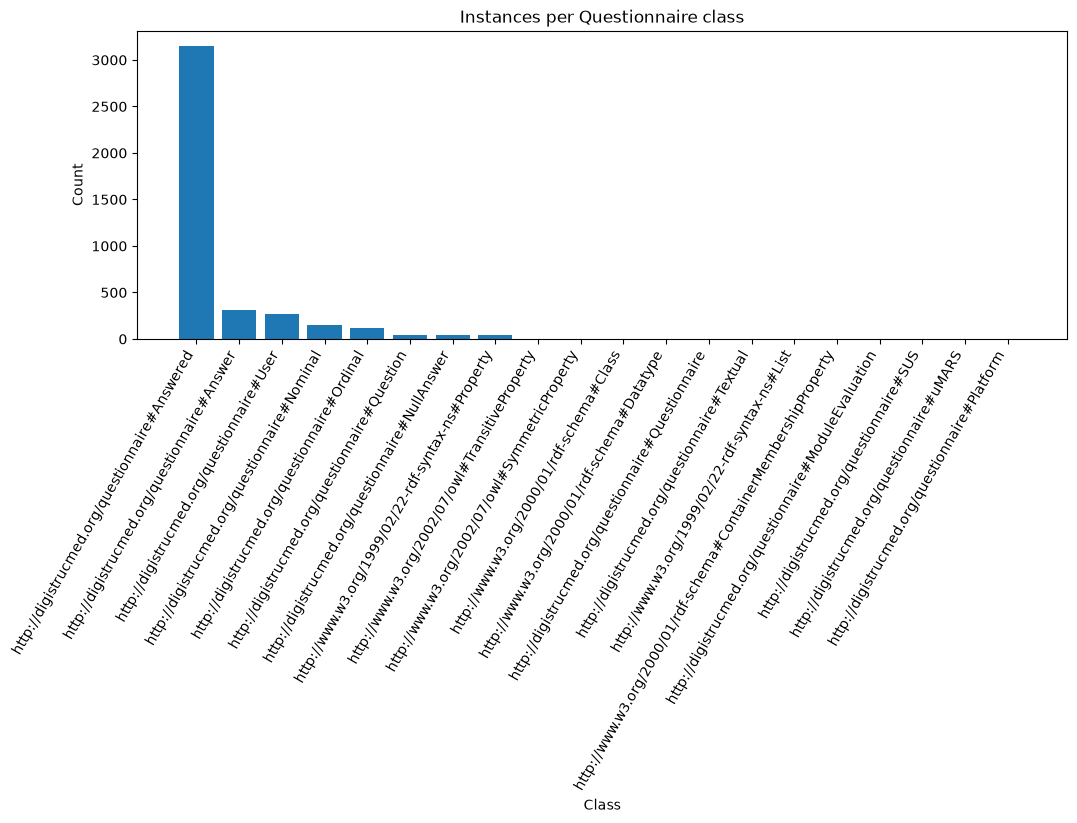

In [6]:

if not df2.empty:
    df2_plot = df2.copy()
    df2_plot["count"] = pd.to_numeric(df2_plot["count"], errors="coerce")
    df2_plot = df2_plot.dropna(subset=["count"])
    plt.figure(figsize=(12, 4))
    plt.xticks(rotation=60, ha="right")
    plt.title("Instances per Questionnaire class")
    plt.ylabel("Count")
    plt.xlabel("Class")
    plt.bar(df2_plot["type"], df2_plot["count"])
    plt.tight_layout()
else:
    print("No data to plot for query 2.")

## 3. List the number of answers are answered by users in each questionnarie.


In [7]:
q3 = """\
SELECT DISTINCT ?user (COUNT(?instance) AS ?count) ?questionnarie
WHERE {
  ?instance rdf:type <http://digistrucmed.org/questionnaire#Answered>;
    <http://digistrucmed.org/questionnaire#answeredByUser> ?user;
    <http://digistrucmed.org/questionnaire#answeredInQuestionnaire> ?questionnarie.
}
GROUP BY ?user ?questionnarie
ORDER BY DESC(?count)
"""

df3 = run_query(q3)
df3

,user,count,questionnarie
0,http://digistrucmed.org/questionnaire#50,24,http://digistrucmed.org/questionnaire#uMARS
1,http://digistrucmed.org/questionnaire#55,24,http://digistrucmed.org/questionnaire#uMARS
2,http://digistrucmed.org/questionnaire#81,24,http://digistrucmed.org/questionnaire#uMARS
3,http://digistrucmed.org/questionnaire#100,24,http://digistrucmed.org/questionnaire#uMARS
4,http://digistrucmed.org/questionnaire#127,24,http://digistrucmed.org/questionnaire#uMARS
...,...,...,...
268,http://digistrucmed.org/questionnaire#425,8,http://digistrucmed.org/questionnaire#ME1
269,http://digistrucmed.org/questionnaire#426,8,http://digistrucmed.org/questionnaire#ME1
270,http://digistrucmed.org/questionnaire#427,8,http://digistrucmed.org/questionnaire#ME1
271,http://digistrucmed.org/questionnaire#429,8,http://digistrucmed.org/questionnaire#ME1


## 4.Network Degree Centrality of Questionnaire Entities
Using predicate edges.

Number of nodes: 3783
Number of edges: 16122


,node,centrality
0,http://digistrucmed.org/questionnaire#1,0.833950
1,http://digistrucmed.org/questionnaire#ME1,0.353252
2,http://digistrucmed.org/questionnaire#uMARS,0.349022
3,http://digistrucmed.org/questionnaire#SUS,0.142782
4,http://digistrucmed.org/questionnaire#M003_01,0.047329
5,http://digistrucmed.org/questionnaire#M006_01,0.047329
6,http://digistrucmed.org/questionnaire#M004_01,0.047329
7,http://digistrucmed.org/questionnaire#M002_01,0.047329
8,http://digistrucmed.org/questionnaire#M010_01,0.047329
9,http://digistrucmed.org/questionnaire#M005,0.045479


Average number of neighbors (overall): 8.523394131641554
Average number of neighbors (subject only): 6.486023958927553
Average number of neighbors (data nodes only): 34.31046931407942
Average shortest path length (largest component): 2.3376582565578734


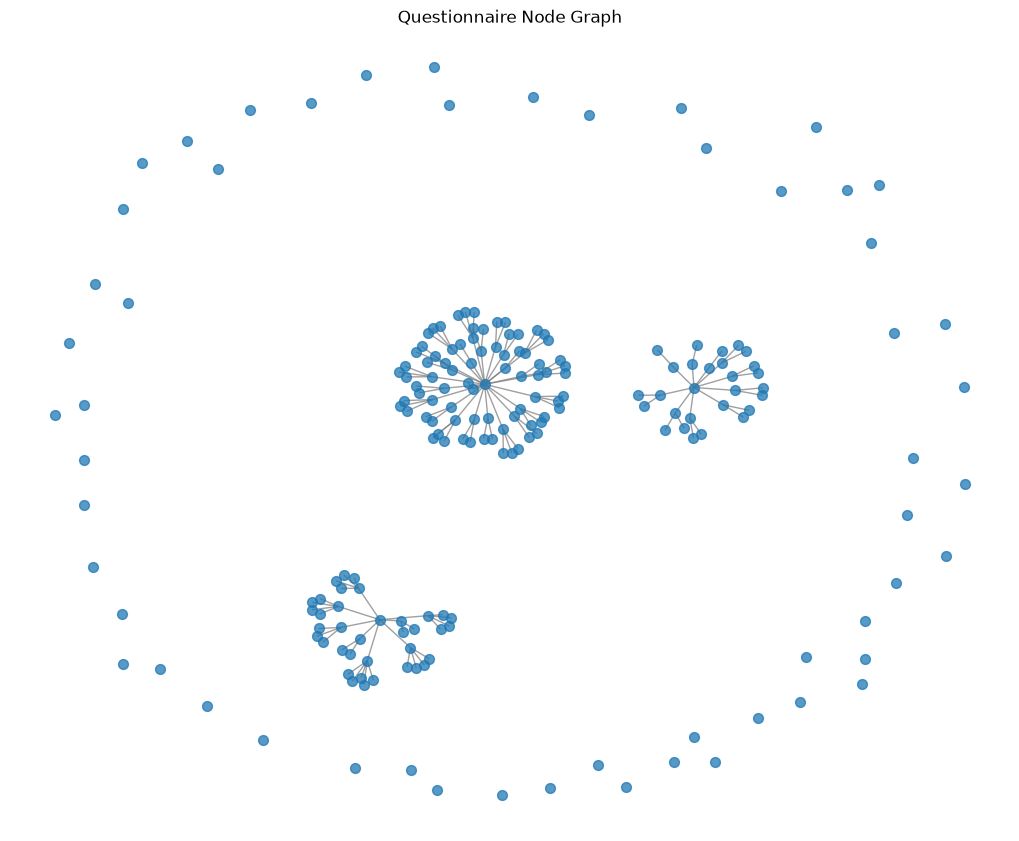

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


# Build questionnaire relations query
q_edges = """
SELECT ?s ?p ?o
WHERE {
    ?s ?p ?o .

    FILTER(?p IN (
        ds:belongsTo,
        ds:hasPossibleAnswer,
        ds:isAnswerTo,
        ds:answeredByUser,
        ds:answeredOnPlatform,
        ds:answeredInQuestionnaire,
        ds:hasQuestion,
        ds:hasAnswer
    ))

    FILTER(isIRI(?s) && isIRI(?o))
}
"""


# Run query
df_edges = run_query(q_edges)

# Build graph
G = nx.Graph()

for _, row in df_edges.iterrows():
    G.add_edge(row["s"], row["o"], predicate=row["p"])

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")


# Degree centrality
degree_centrality = nx.degree_centrality(G)

df_degree = (
    pd.DataFrame(degree_centrality.items(), columns=["node", "centrality"])
    .sort_values("centrality", ascending=False)
    .reset_index(drop=True)
)

display(df_degree.head(20))


# Average degree / neighbors
degrees = dict(G.degree())

avg_neighbors = (
    sum(degrees.values()) / len(degrees)
    if degrees
    else 0
)

print(f"Average number of neighbors (overall): {avg_neighbors}")


# Pattern nodes: subjects from queried relations
subjects_nodes = set(df_edges["s"].unique())

subjects_degrees = [
    degrees[node]
    for node in subjects_nodes
    if node in degrees
]

if subjects_degrees:
    avg_neighbors_subjects = sum(subjects_degrees) / len(subjects_degrees)
    print(f"Average number of neighbors (subject only): {avg_neighbors_subjects}")


# Data nodes: objects that are not also subjects nodes
data_nodes = set(df_edges["o"].unique()) - subjects_nodes

data_degrees = [
    degrees[node]
    for node in data_nodes
    if node in degrees
]

if data_degrees:
    avg_neighbors_data = sum(data_degrees) / len(data_degrees)
    print(f"Average number of neighbors (data nodes only): {avg_neighbors_data}")


# Average shortest path length on the largest connected component
if G.number_of_nodes() > 0:
    try:
        if nx.is_connected(G):
            component_graph = G
        else:
            largest_component = max(nx.connected_components(G), key=len)
            component_graph = G.subgraph(largest_component).copy()

        avg_shortest_path = nx.average_shortest_path_length(component_graph)
        print(
            "Average shortest path length "
            f"(largest component): {avg_shortest_path}"
        )

    except nx.NetworkXError as error:
        print(f"Could not compute average shortest path length: {error}")


# Network visualization
max_nodes_to_plot = 200

if G.number_of_nodes() > max_nodes_to_plot:
    top_nodes = [
        node
        for node, _ in sorted(
            G.degree,
            key=lambda item: item[1],
            reverse=True
        )[:max_nodes_to_plot]
    ]

    plot_graph = G.subgraph(top_nodes).copy()
else:
    plot_graph = G

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(plot_graph, seed=0)

nx.draw(
    plot_graph,
    pos,
    with_labels=False,
    node_size=50,
    edge_color="gray",
    alpha=0.75,
)

plt.title("Questionnaire Node Graph")
plt.axis("off")
plt.show()

,type_short,number_of_nodes,average_degree,median_degree,max_degree
6,Platform,1,3154.000000,3154.0,3154
2,ModuleEvaluation,1,1336.000000,1336.0,1336
12,uMARS,1,1320.000000,1320.0,1320
8,Questionnaire,3,1065.333333,1320.0,1336
9,SUS,1,540.000000,540.0,540
7,Question,42,83.476190,62.0,179
10,Textual,2,81.000000,81.0,100
4,NullAnswer,42,13.928571,11.0,106
5,Ordinal,115,11.956522,6.0,67
11,User,273,11.553114,8.0,24


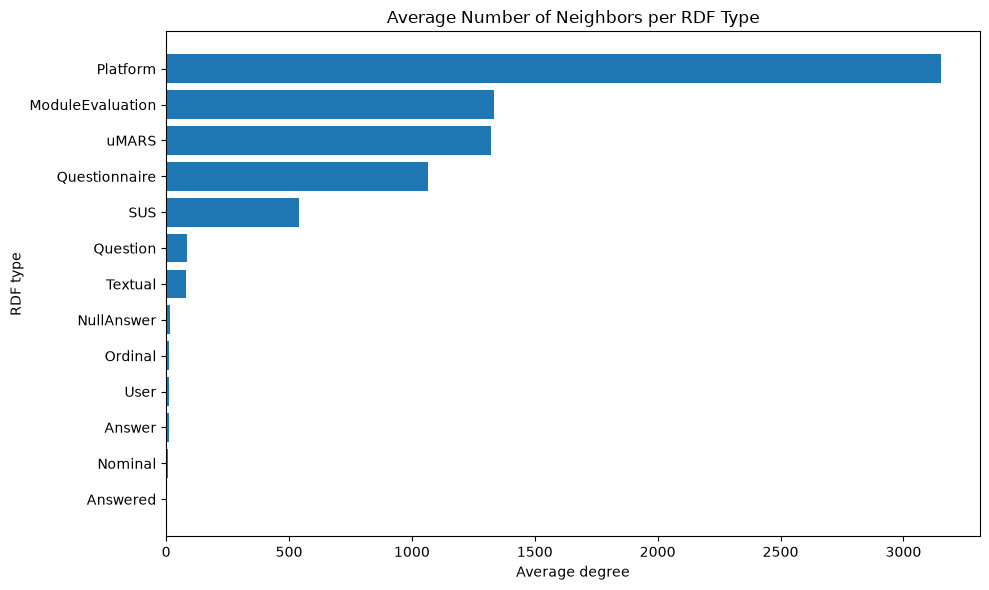

In [9]:
# ------------------------------------------------------------
# Average degree per RDF type
# ------------------------------------------------------------

q_types = """
SELECT DISTINCT ?node ?type
WHERE {
    ?node rdf:type ?type .
}
"""

df_types = run_query(q_types)

def short_uri(x):
    if pd.isna(x):
        return x
    x = str(x)
    return x.split("#")[-1] if "#" in x else x.rstrip("/").split("/")[-1]

df_types["node_short"] = df_types["node"].apply(short_uri)
df_types["type_short"] = df_types["type"].apply(short_uri)

# Add degree value from NetworkX graph
df_types["degree"] = df_types["node"].map(degrees)

# Keep only nodes that are actually in the analyzed graph
df_types = df_types.dropna(subset=["degree"])
df_types["degree"] = df_types["degree"].astype(int)

# Statistics per RDF type
df_degree_by_type = (
    df_types
    .groupby("type_short")
    .agg(
        number_of_nodes=("node", "nunique"),
        average_degree=("degree", "mean"),
        median_degree=("degree", "median"),
        max_degree=("degree", "max")
    )
    .reset_index()
    .sort_values("average_degree", ascending=False)
)

display(df_degree_by_type)

plt.figure(figsize=(10, 6))
plt.barh(
    df_degree_by_type["type_short"],
    df_degree_by_type["average_degree"]
)
plt.gca().invert_yaxis()
plt.xlabel("Average degree")
plt.ylabel("RDF type")
plt.title("Average Number of Neighbors per RDF Type")
plt.tight_layout()
plt.show()

,question_short,questionText,responseCode,answer,frequency,percentage
0,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,10,sehr [10],61,22.93
1,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,8,[8],44,16.54
2,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,8,Skalenwert 8,44,16.54
3,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,9,[9],29,10.90
4,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,9,Skalenwert 9,29,10.90
...,...,...,...,...,...,...
95,SU01_01,"System Usability Scale (SUS): Ich denke, ich w�rde die Lernplattform gerne h�ufiger benutzen.",3,Likert response 3,20,37.74
96,SU01_01,"System Usability Scale (SUS): Ich denke, ich w�rde die Lernplattform gerne h�ufiger benutzen.",5,trifft voll zu,11,20.75
97,SU01_01,"System Usability Scale (SUS): Ich denke, ich w�rde die Lernplattform gerne h�ufiger benutzen.",4,Likert response 4,11,20.75
98,SU01_01,"System Usability Scale (SUS): Ich denke, ich w�rde die Lernplattform gerne h�ufiger benutzen.",NaN,No recorded response,8,15.09


,responseCode,answer,frequency,percentage
55,10,sehr gut [10],55,20.22
56,8,[8],46,16.91
57,8,Skalenwert 8,46,16.91
58,9,[9],34,12.50
59,9,Skalenwert 9,34,12.50
60,7,[7],12,4.41
61,7,Skalenwert 7,12,4.41
62,6,[6],8,2.94
63,6,Skalenwert 6,8,2.94
64,5,[5],4,1.47


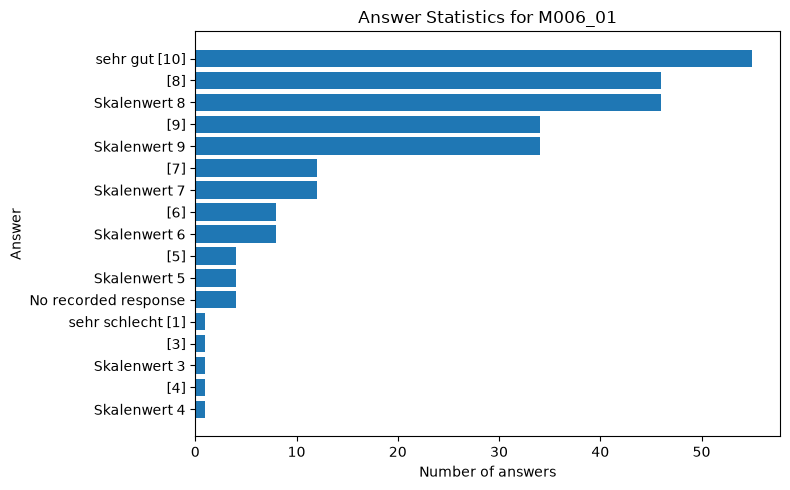

,responseCode,answer,frequency,percentage
108,NaN,No recorded response,543,14.70
103,8,Skalenwert 8,185,5.01
105,9,Skalenwert 9,185,5.01
104,8,[8],185,5.01
106,9,[9],185,5.01
107,TEXT,Textual response,160,4.33
72,4,Likert response 4,134,3.63
96,5,trifft gar nicht zu,114,3.09
18,10,sehr gut [10],114,3.09
55,4,4,112,3.03


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Helper
def short_uri(x):
    if pd.isna(x):
        return x
    x = str(x)
    return x.split("#")[-1] if "#" in x else x

# ------------------------------------------------------------
# Simple answer statistics per question
# ------------------------------------------------------------

q_answer_stats = """
SELECT
    ?question
    ?questionText
    ?responseCode
    ?responseLabel
    (COUNT(DISTINCT ?answered) AS ?frequency)
WHERE {
    ?answered ds:hasQuestion ?question ;
              ds:hasAnswer ?answer .

    OPTIONAL { ?question ds:QuestionDescription ?questionText . }
    OPTIONAL { ?answer ds:ResponseCode ?responseCode . }
    OPTIONAL { ?answer ds:ResponseLabel ?responseLabel . }
}
GROUP BY ?question ?questionText ?responseCode ?responseLabel
ORDER BY ?question DESC(?frequency)
"""

df = run_query(q_answer_stats)

df["frequency"] = df["frequency"].astype(int)
df["question_short"] = df["question"].apply(short_uri)

df["answer"] = df["responseLabel"].fillna(df["responseCode"])
df["total_per_question"] = df.groupby("question")["frequency"].transform("sum")

df["percentage"] = (
    df["frequency"] / df["total_per_question"] * 100
).round(2)

df = df.sort_values(
    ["question_short", "frequency"],
    ascending=[True, False]
)

display(df[[
    "question_short",
    "questionText",
    "responseCode",
    "answer",
    "frequency",
    "percentage"
]].head(100))

# For one specific question, show the distribution of answers
question_id = "M006_01"   # change this

one_question = df[df["question_short"] == question_id]

display(one_question[[
    "responseCode",
    "answer",
    "frequency",
    "percentage"
]])

plt.figure(figsize=(8, 5))
plt.barh(one_question["answer"], one_question["frequency"])
plt.gca().invert_yaxis()
plt.xlabel("Number of answers")
plt.ylabel("Answer")
plt.title(f"Answer Statistics for {question_id}")
plt.tight_layout()
plt.show()

#For an overall view, show the most common answers across all questions
overall = (
    df.groupby(["responseCode", "answer"], dropna=False)["frequency"]
    .sum()
    .reset_index()
    .sort_values("frequency", ascending=False)
)

overall["percentage"] = (
    overall["frequency"] / overall["frequency"].sum() * 100
).round(2)

display(overall.head(30))